# Missing Values — Detection & Handling

Missing data is one of the most common data quality issues. Choosing the wrong handling strategy can bias your analysis or degrade model performance.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print("Shape:", df.shape)

Shape: (891, 15)


## Why Does Missing Data Occur?

| Cause | Example |
|---|---|
| Data entry errors | Typographical errors, skipped form fields |
| Incomplete records | Respondents skip survey questions |
| Data merging issues | Misaligned records from different sources |
| System/sensor failures | Sensor malfunction, software bugs |
| Non-applicability | Sunroof field for cars without sunroofs |

Understanding *why* data is missing is critical for choosing the right strategy:
- **MCAR** (Missing Completely at Random) — removal is safe
- **MAR** (Missing at Random) — imputation based on other features works
- **MNAR** (Missing Not at Random) — requires careful domain-specific handling

In [2]:
# Detect missing values
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)

summary = pd.DataFrame({'Count': missing_count, 'Percent': missing_pct})
summary = summary[summary['Count'] > 0].sort_values('Percent', ascending=False)
print(summary)

             Count  Percent
deck           688    77.22
age            177    19.87
embarked         2     0.22
embark_town      2     0.22


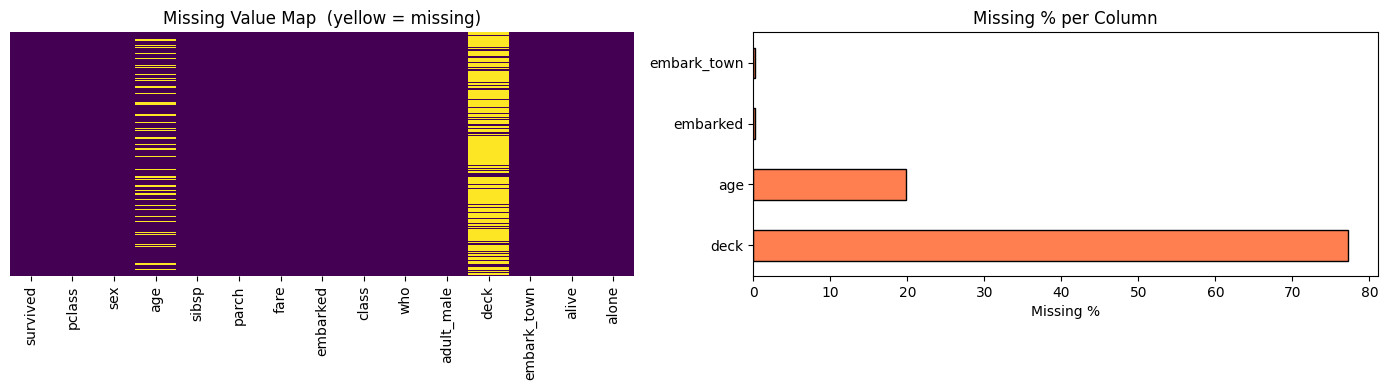

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[0])
axes[0].set_title('Missing Value Map  (yellow = missing)')

# Bar chart of missing %
summary['Percent'].plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Missing % per Column')
axes[1].set_xlabel('Missing %')

plt.tight_layout()
plt.show()

## Strategy 1: Removal

**When to use**: missing proportion is small (< 5%) and data loss won't bias the analysis.

**Risk**: if missingness is not random, removing rows can introduce bias.

In [4]:
# Row removal — drop rows where 'embarked' is missing (only 2 rows)
df_row_removed = df.dropna(subset=['embarked'])
print(f"Row removal — embarked: {len(df)} → {len(df_row_removed)} rows")

# Column removal — drop 'deck' which is 77% missing
df_col_removed = df.drop(columns=['deck'])
print(f"Column removal — deck dropped: {df.shape[1]} → {df_col_removed.shape[1]} columns")

Row removal — embarked: 891 → 889 rows
Column removal — deck dropped: 15 → 14 columns


## Strategy 2: Statistical Imputation

Replace missing values with a summary statistic of the non-missing values.

| Statistic | When to use |
|---|---|
| **Mean** | Numerical, symmetric distribution, no extreme outliers |
| **Median** | Numerical, skewed distribution or outliers present |
| **Mode** | Categorical columns |

In [5]:
df_imputed = df.copy()

# Age — right-skewed → use median
age_median = df_imputed['age'].median()
df_imputed['age'] = df_imputed['age'].fillna(age_median)

# Embarked — categorical → use mode
embarked_mode = df_imputed['embarked'].mode()[0]
df_imputed['embarked'] = df_imputed['embarked'].fillna(embarked_mode)

print(f"Age imputed with median = {age_median}")
print(f"Embarked imputed with mode = '{embarked_mode}'")
print(f"Missing after imputation: {df_imputed[['age', 'embarked']].isnull().sum().to_dict()}")

Age imputed with median = 28.0
Embarked imputed with mode = 'S'
Missing after imputation: {'age': 0, 'embarked': 0}


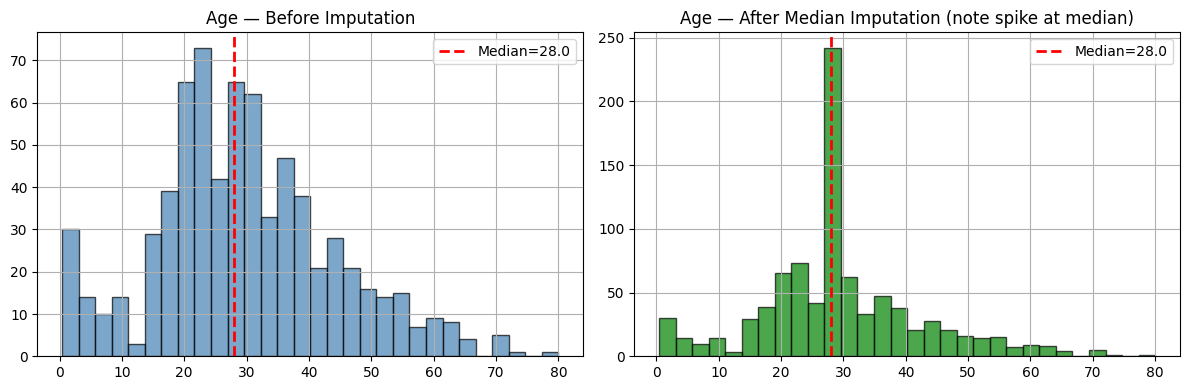

In [6]:
# Visualise: imputation creates a spike at the imputed value
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['age'].dropna().hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(age_median, color='red', linewidth=2, linestyle='--', label=f'Median={age_median}')
axes[0].set_title('Age — Before Imputation')
axes[0].legend()

df_imputed['age'].hist(bins=30, ax=axes[1], color='green', edgecolor='black', alpha=0.7)
axes[1].axvline(age_median, color='red', linewidth=2, linestyle='--', label=f'Median={age_median}')
axes[1].set_title('Age — After Median Imputation (note spike at median)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Strategy 3: Forward / Backward Fill

Used for **time-ordered data** where the missing value follows the logical sequence of surrounding values.

- **Forward fill (ffill)**: use the last known value before the gap
- **Backward fill (bfill)**: use the next known value after the gap
- **Linear interpolation**: assume a straight line between neighbouring known values

Original:           [10.0, nan, nan, 25.0, nan, 40.0, nan]
Forward fill:       [10.0, 10.0, 10.0, 25.0, 25.0, 40.0, 40.0]
Backward fill:      [10.0, 25.0, 25.0, 25.0, 40.0, 40.0, nan]
Linear interp:      [10.0, 15.0, 20.0, 25.0, 32.5, 40.0, 40.0]


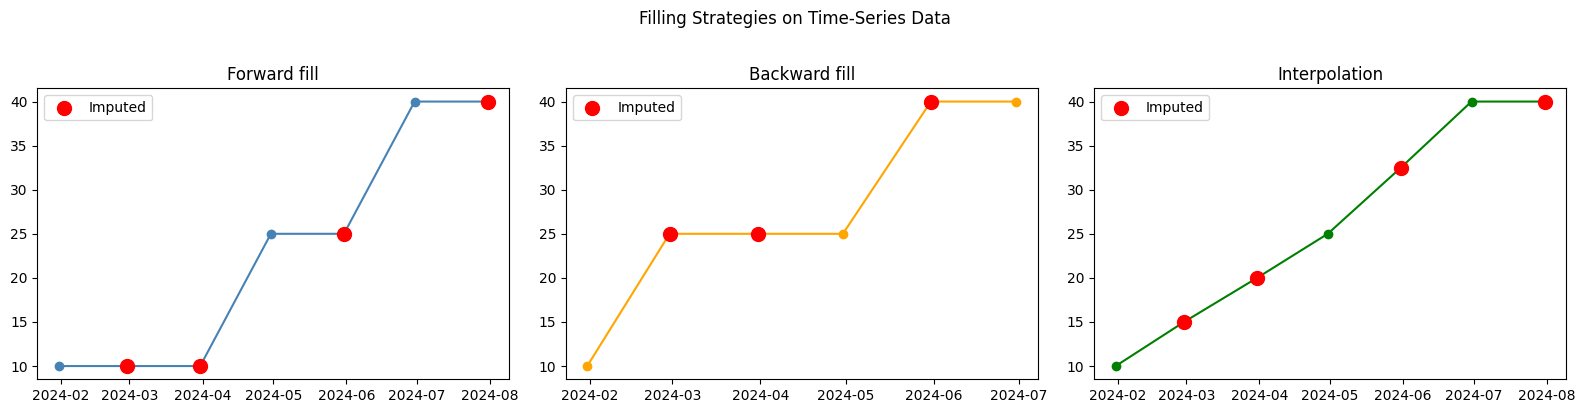

In [7]:
# Time-series example
ts = pd.Series([10.0, np.nan, np.nan, 25.0, np.nan, 40.0, np.nan],
               index=pd.date_range('2024-01', periods=7, freq='ME'))

print("Original:          ", ts.tolist())
print("Forward fill:      ", ts.ffill().tolist())
print("Backward fill:     ", ts.bfill().tolist())
print("Linear interp:     ", ts.interpolate('linear').tolist())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (method, filled), color in zip(axes,
    [('Forward fill', ts.ffill()), ('Backward fill', ts.bfill()), ('Interpolation', ts.interpolate())],
    ['steelblue', 'orange', 'green']
):
    ax.plot(ts.index, filled, color=color, marker='o')
    ax.scatter(ts.index[ts.isna()], filled[ts.isna()], color='red', zorder=5,
               s=100, label='Imputed')
    ax.set_title(method)
    ax.legend()

plt.suptitle('Filling Strategies on Time-Series Data', y=1.02)
plt.tight_layout()
plt.show()

## Strategy 4: KNN Imputation

Finds the K most similar records (neighbours) for each row with missing data, and imputes using the average of those neighbours' values.

Best when:
- Features are correlated (similar records share similar missing values)
- Dataset is not too large (KNN is computationally expensive)
- Missing data has a pattern that can be inferred from other features

In [8]:
num_cols = ['age', 'fare', 'pclass', 'sibsp', 'parch']
df_knn_input = df[num_cols].copy()

imputer = KNNImputer(n_neighbors=5)
df_knn_filled = pd.DataFrame(
    imputer.fit_transform(df_knn_input),
    columns=num_cols
)

print(f"Missing before KNN: {df_knn_input['age'].isnull().sum()}")
print(f"Missing after KNN:  {df_knn_filled['age'].isnull().sum()}")
print()
print("Comparison — Age distribution:")
print(pd.DataFrame({
    'original (no NaN)': df['age'].dropna().describe(),
    'KNN imputed':       df_knn_filled['age'].describe()
}).round(2))

Missing before KNN: 177
Missing after KNN:  0

Comparison — Age distribution:
       original (no NaN)  KNN imputed
count             714.00       891.00
mean               29.70        29.86
std                14.53        13.39
min                 0.42         0.42
25%                20.12        22.00
50%                28.00        29.00
75%                38.00        37.00
max                80.00        80.00


## Strategy 5: Regression Imputation

Treats the column with missing values as the **dependent variable** and trains a regression model using the other features to predict the missing values.

- More accurate than mean/median imputation because it uses relationships between features
- Preserves correlations between the imputed feature and its predictors
- Risk: if the predictor features are weak, the predictions add noise rather than signal
- Should not be applied before the train/test split (the regressor must be fit on train only)

Missing before: 177
Missing after:  0



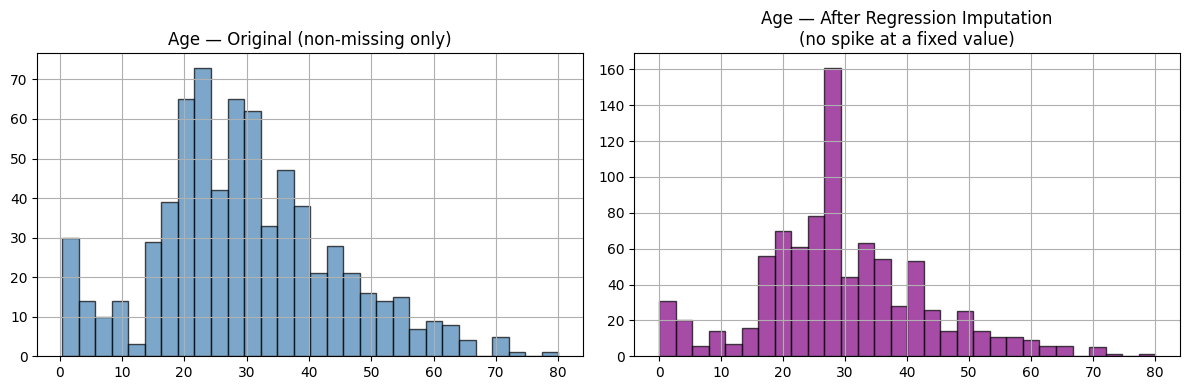

Regression imputation preserves the spread of the distribution better than median imputation.


In [9]:
from sklearn.linear_model import LinearRegression

# Separate rows: known age vs missing age
df_reg = df[['age', 'fare', 'pclass', 'sibsp', 'parch']].copy()
predictor_cols = ['fare', 'pclass', 'sibsp', 'parch']

known   = df_reg[df_reg['age'].notna()]
missing = df_reg[df_reg['age'].isna()]

# Train a linear regression on the rows where age is known
reg = LinearRegression()
reg.fit(known[predictor_cols], known['age'])

# Predict age for the rows where it is missing
predicted_ages = reg.predict(missing[predictor_cols])
predicted_ages = np.clip(predicted_ages, 0, 80)  # ensure plausible range

df_reg_filled = df_reg.copy()
df_reg_filled.loc[df_reg_filled['age'].isna(), 'age'] = predicted_ages

print(f"Missing before: {df_reg['age'].isna().sum()}")
print(f"Missing after:  {df_reg_filled['age'].isna().sum()}")
print()

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
known['age'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Age — Original (non-missing only)')

df_reg_filled['age'].hist(bins=30, ax=axes[1], color='purple', edgecolor='black', alpha=0.7)
axes[1].set_title('Age — After Regression Imputation\n(no spike at a fixed value)')

plt.tight_layout()
plt.show()

print("Regression imputation preserves the spread of the distribution better than median imputation.")

## Strategy 6: Using Algorithms That Handle Missing Values Natively

Certain ML algorithms can work directly with missing values — no imputation required. They route missing values down both branches of a split (or similar mechanisms) and learn the optimal path from data.

| Algorithm | How it handles missing values |
|---|---|
| **Decision Tree** | Surrogate splits: tries alternative features when the primary split feature is missing |
| **Random Forest** | Each tree handles missingness independently via surrogate splits |
| **XGBoost** | Learns a default direction for missing values at each split |
| **LightGBM** | Native NaN support via its histogram-based split algorithm |

When to use this approach:
- Dataset is large and imputation overhead is costly
- Missingness pattern itself carries signal (MNAR scenarios)
- Quick baseline model without a separate preprocessing pipeline

## Choosing a Strategy

| Situation | Recommended Strategy |
|---|---|
| < 5% missing, random | Row removal |
| > 40% missing in a column | Column removal |
| Numerical, symmetric | Mean imputation |
| Numerical, skewed | Median imputation |
| Categorical | Mode imputation |
| Time-series | Forward/backward fill or interpolation |
| Features are correlated | KNN imputation |

**Key principle**: understand *why* data is missing before picking a method.